# 02 — Exploratory Analysis
> **Superstore Sales Analytics | Future Interns DS Task 1**

This notebook answers the five core business questions using the cleaned dataset.

---
### Business Questions
1. How have sales & profit trended from 2014–2017?
2. Which categories and sub-categories drive (or destroy) profit?
3. Which regions and states should the business prioritise?
4. How does discounting affect profitability?
5. Which customer segments are most valuable?

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11
})

FIGURES = '../reports/figures'
os.makedirs(FIGURES, exist_ok=True)

def save_fig(name):
    path = f'{FIGURES}/{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved → {path}')

df = pd.read_csv('../dataset/processed/superstore_clean.csv', parse_dates=['Order Date', 'Ship Date'])

# Re-create YearMonth period for time-series grouping
df['YearMonth'] = df['Order Date'].dt.to_period('M')

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns ✓')

Loaded: 9,994 rows x 30 columns ✓


## 1. High-Level KPIs

In [2]:
total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin       = total_profit / total_sales * 100
n_orders     = df['Order ID'].nunique()
n_customers  = df['Customer ID'].nunique()
avg_order    = df.groupby('Order ID')['Sales'].sum().mean()

kpis = pd.DataFrame({
    'KPI': ['Total Revenue', 'Total Profit', 'Profit Margin', 'Unique Orders', 'Unique Customers', 'Avg Order Value'],
    'Value': [f'${total_sales:,.0f}', f'${total_profit:,.0f}', f'{margin:.1f}%',
              f'{n_orders:,}', f'{n_customers:,}', f'${avg_order:,.0f}']
})
kpis

,KPI,Value
0,Total Revenue,"$2,297,201"
1,Total Profit,"$286,397"
2,Profit Margin,12.5%
3,Unique Orders,"5,009"
4,Unique Customers,793
5,Avg Order Value,$459


## 2. Sales & Profit Trends (2014–2017)

Saved → ../reports/figures/monthly_sales_trend.png


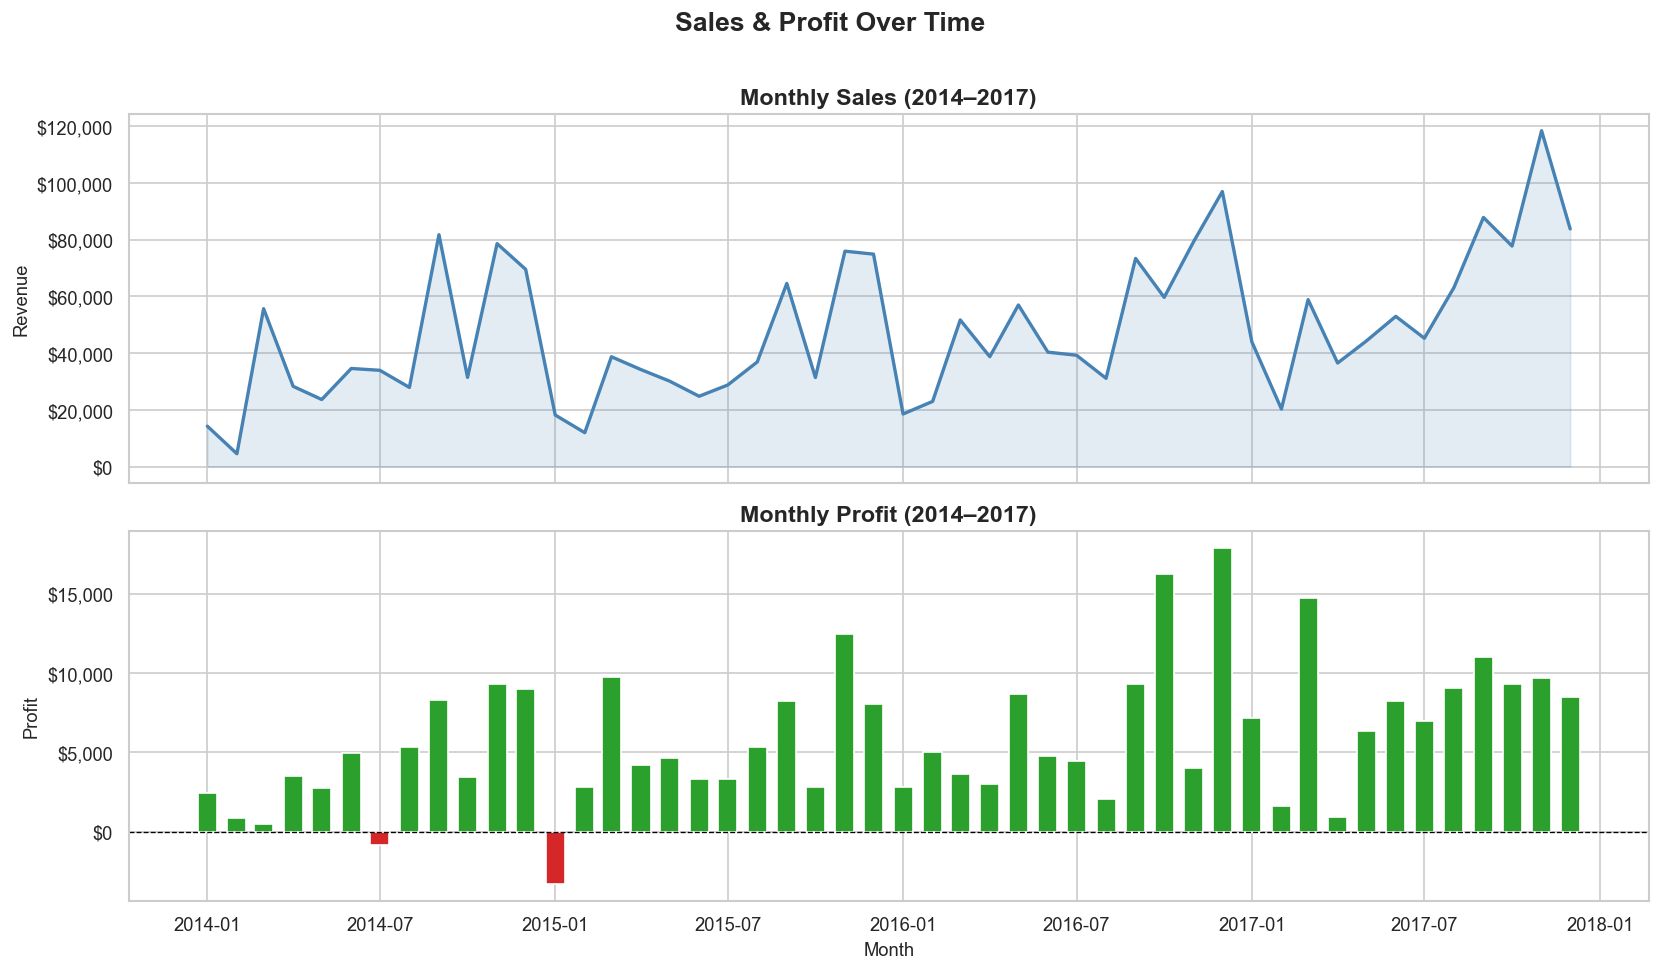

In [3]:
# Monthly aggregation
monthly = (
    df.groupby('YearMonth')[['Sales', 'Profit']]
    .sum()
    .reset_index()
)
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Sales
axes[0].plot(monthly['YearMonth_dt'], monthly['Sales'], color='steelblue', linewidth=2)
axes[0].fill_between(monthly['YearMonth_dt'], monthly['Sales'], alpha=0.15, color='steelblue')
axes[0].set_title('Monthly Sales (2014–2017)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_ylabel('Revenue')

# Profit
colors = ['#d62728' if p < 0 else '#2ca02c' for p in monthly['Profit']]
axes[1].bar(monthly['YearMonth_dt'], monthly['Profit'], color=colors, width=20)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Monthly Profit (2014–2017)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_ylabel('Profit')
axes[1].set_xlabel('Month')

plt.suptitle('Sales & Profit Over Time', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('monthly_sales_trend')
plt.show()

In [4]:
# Year-over-year growth
yearly = df.groupby('Year')[['Sales', 'Profit']].sum()
yearly['Sales Growth %']  = yearly['Sales'].pct_change() * 100
yearly['Profit Growth %'] = yearly['Profit'].pct_change() * 100
yearly['Margin %']        = yearly['Profit'] / yearly['Sales'] * 100
yearly.style.format({'Sales': '${:,.0f}', 'Profit': '${:,.0f}',
                     'Sales Growth %': '{:.1f}%', 'Profit Growth %': '{:.1f}%',
                     'Margin %': '{:.1f}%'})

,Sales,Profit,Sales Growth %,Profit Growth %,Margin %
Year,,,,,
2014,"$484,247","$49,544",nan%,nan%,10.2%
2015,"$470,533","$61,619",-2.8%,24.4%,13.1%
2016,"$609,206","$81,795",29.5%,32.7%,13.4%
2017,"$733,215","$93,439",20.4%,14.2%,12.7%


Saved → ../reports/figures/quarterly_sales_by_year.png


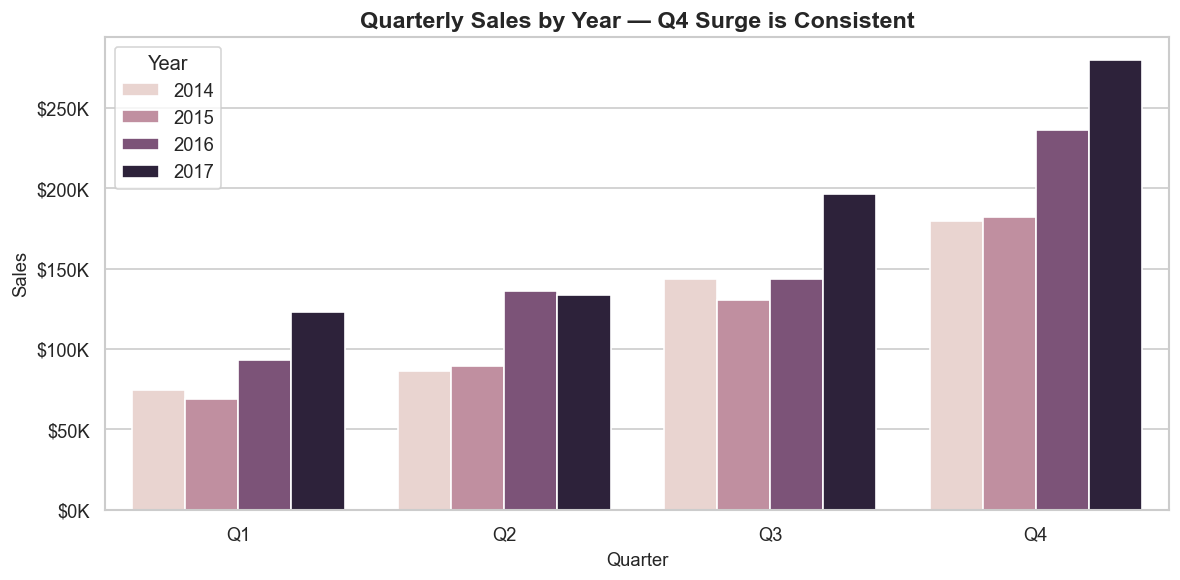

In [5]:
# Seasonal pattern — average sales by quarter across all years
quarterly = df.groupby(['Year', 'Quarter Label'])['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=quarterly, x='Quarter Label', y='Sales', hue='Year', ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Quarterly Sales by Year — Q4 Surge is Consistent')
ax.set_ylabel('Sales')
ax.set_xlabel('Quarter')
plt.tight_layout()
save_fig('quarterly_sales_by_year')
plt.show()

## 3. Category & Sub-Category Analysis

In [6]:
cat = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).assign(Margin=lambda x: x['Profit'] / x['Sales'] * 100).sort_values('Profit', ascending=False)

print('Category Summary:')
cat.style.format({'Sales': '${:,.0f}', 'Profit': '${:,.0f}', 'Margin': '{:.1f}%'})

Category Summary:


,Sales,Profit,Orders,Margin
Category,,,,
Technology,"$836,154","$145,455",1544,17.4%
Office Supplies,"$719,047","$122,491",3742,17.0%
Furniture,"$742,000","$18,451",1764,2.5%


Saved → ../reports/figures/subcategory_profit.png


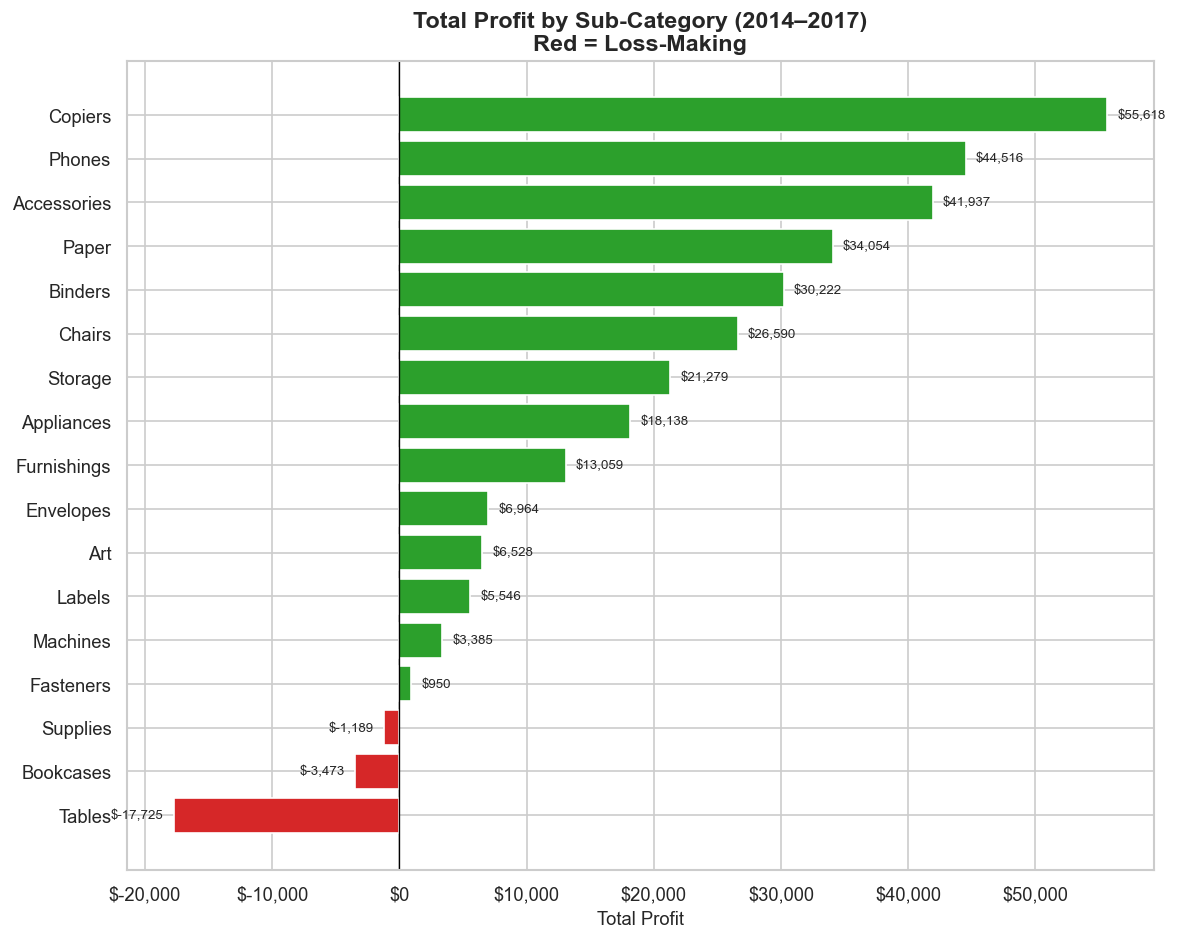

In [7]:
# Sub-category profit — the most revealing chart in the whole project
subcat = (
    df.groupby(['Category', 'Sub-Category'])
    .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
    .assign(Margin=lambda x: x['Profit'] / x['Sales'] * 100)
    .reset_index()
    .sort_values('Profit')
)

colors = ['#d62728' if p < 0 else '#2ca02c' for p in subcat['Profit']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(subcat['Sub-Category'], subcat['Profit'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Total Profit by Sub-Category (2014–2017)\nRed = Loss-Making', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit')

# Annotate values
for bar, val in zip(bars, subcat['Profit']):
    ax.text(
        val + (800 if val >= 0 else -800),
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center', ha='left' if val >= 0 else 'right', fontsize=8
    )

plt.tight_layout()
save_fig('subcategory_profit')
plt.show()

Saved → ../reports/figures/sales_vs_profit_scatter.png


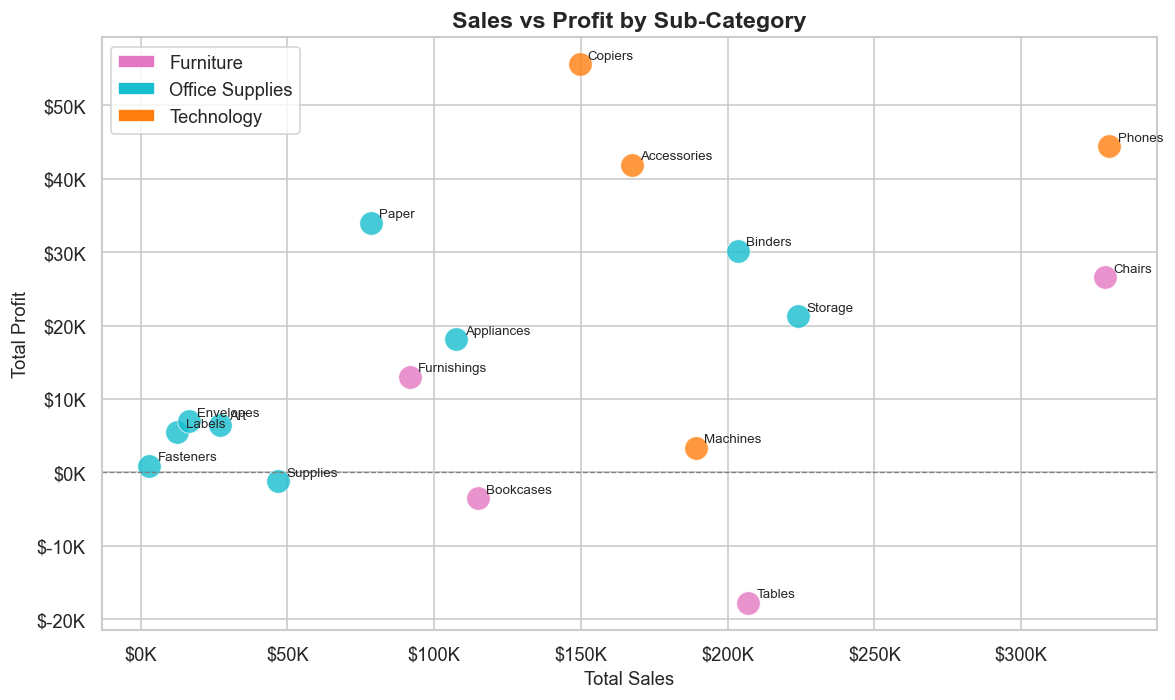

In [8]:
# Sales vs Profit scatter — bubble = quantity sold
fig, ax = plt.subplots(figsize=(10, 6))

category_colors = {'Furniture': '#e377c2', 'Office Supplies': '#17becf', 'Technology': '#ff7f0e'}

for _, row in subcat.iterrows():
    ax.scatter(
        row['Sales'], row['Profit'],
        color=category_colors[row['Category']],
        s=200, alpha=0.8, edgecolors='white', linewidths=0.5
    )
    ax.annotate(row['Sub-Category'], (row['Sales'], row['Profit']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in category_colors.items()]
ax.legend(handles=legend_elements)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Sales vs Profit by Sub-Category', fontweight='bold')
ax.set_xlabel('Total Sales')
ax.set_ylabel('Total Profit')
plt.tight_layout()
save_fig('sales_vs_profit_scatter')
plt.show()

## 4. Regional Performance

In [9]:
region = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique')
).assign(
    Margin=lambda x: x['Profit'] / x['Sales'] * 100,
    Revenue_Share=lambda x: x['Sales'] / x['Sales'].sum() * 100
).sort_values('Profit', ascending=False)

region.style.format({
    'Sales': '${:,.0f}', 'Profit': '${:,.0f}',
    'Margin': '{:.1f}%', 'Revenue_Share': '{:.1f}%'
})

,Sales,Profit,Orders,Customers,Margin,Revenue_Share
Region,,,,,,
West,"$725,458","$108,418",1611,686,14.9%,31.6%
East,"$678,781","$91,523",1401,674,13.5%,29.5%
South,"$391,722","$46,749",822,512,11.9%,17.1%
Central,"$501,240","$39,706",1175,629,7.9%,21.8%


Saved → ../reports/figures/regional_performance.png


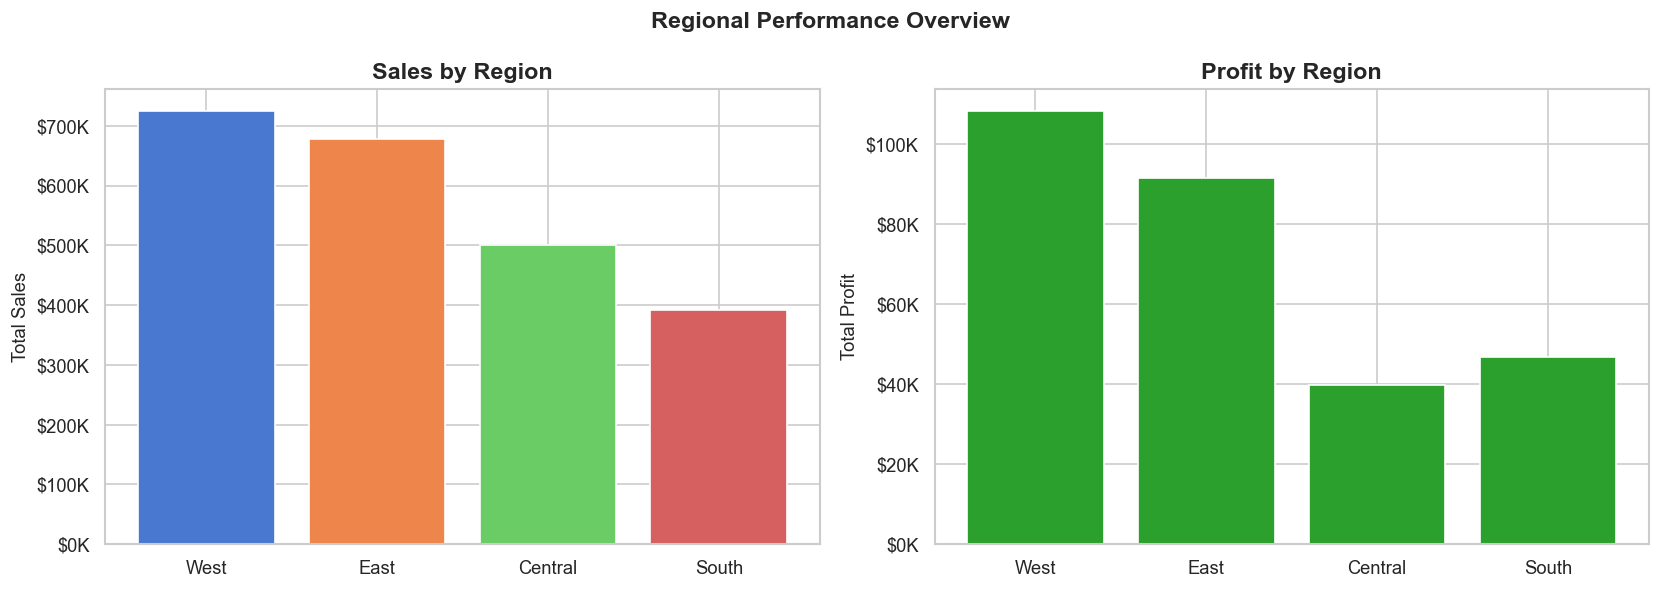

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_sorted = region.sort_values('Sales', ascending=False)

# Sales bar
axes[0].bar(region_sorted.index, region_sorted['Sales'],
            color=sns.color_palette('muted', 4))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].set_title('Sales by Region')
axes[0].set_ylabel('Total Sales')

# Profit bar
profit_colors = ['#d62728' if p < 0 else '#2ca02c' for p in region_sorted['Profit']]
axes[1].bar(region_sorted.index, region_sorted['Profit'], color=profit_colors)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Profit by Region')
axes[1].set_ylabel('Total Profit')

plt.suptitle('Regional Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('regional_performance')
plt.show()

Saved → ../reports/figures/state_profit_top_bottom.png


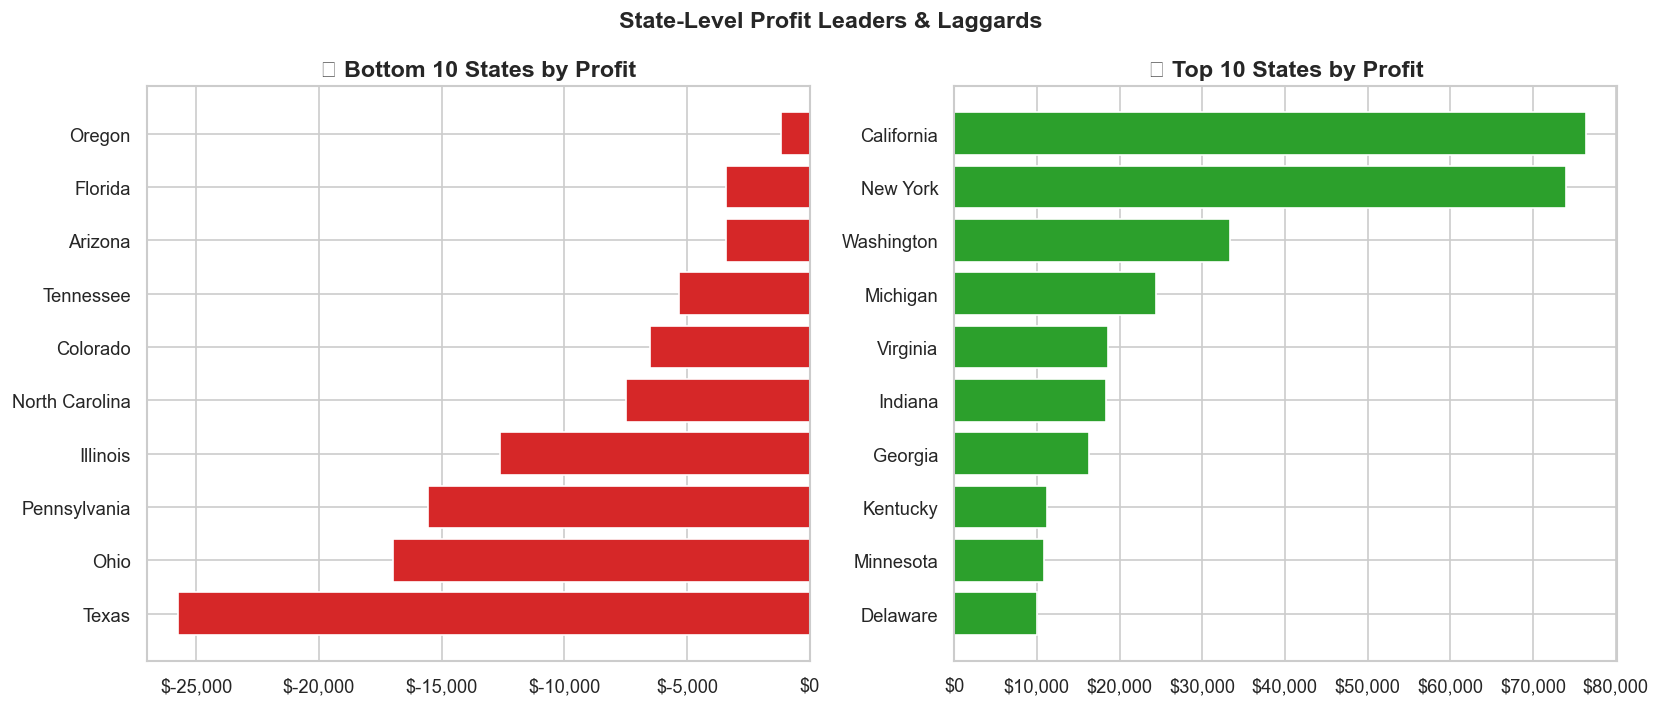

In [11]:
# Top 10 and Bottom 10 states by profit
state_profit = df.groupby('State')['Profit'].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bottom 10
bottom = state_profit.head(10)
axes[0].barh(bottom.index, bottom.values, color='#d62728')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_title('🔴 Bottom 10 States by Profit')

# Top 10
top = state_profit.tail(10)
axes[1].barh(top.index, top.values, color='#2ca02c')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('🟢 Top 10 States by Profit')

plt.suptitle('State-Level Profit Leaders & Laggards', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('state_profit_top_bottom')
plt.show()

## 5. Discount Impact Analysis

Saved → ../reports/figures/discount_vs_profit.png


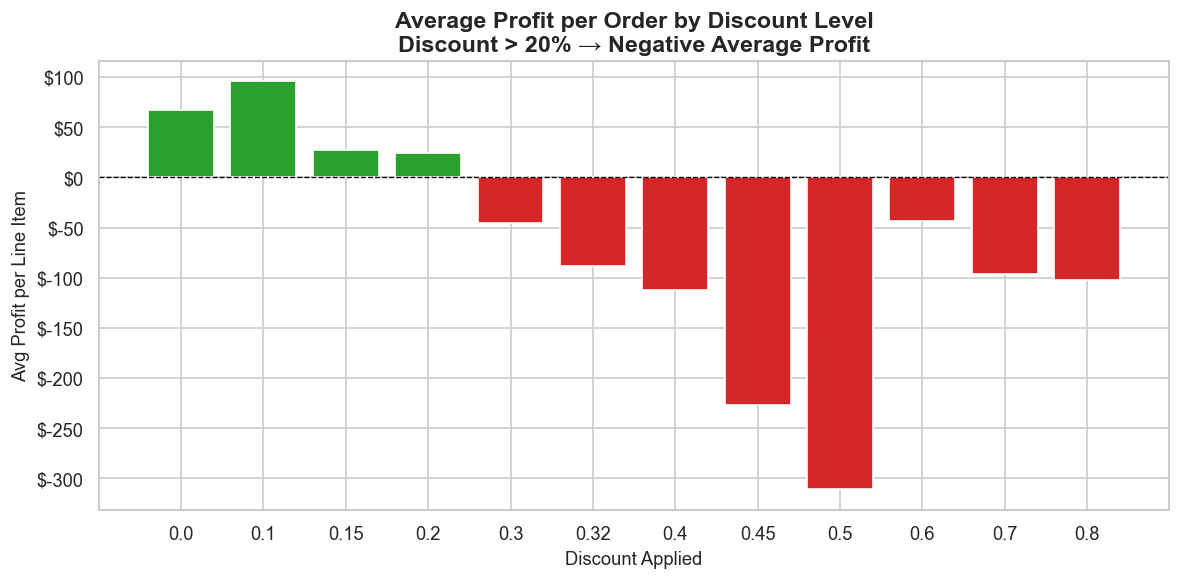

In [12]:
# Average profit by discount level
disc_impact = (
    df.groupby('Discount')
    .agg(Avg_Profit=('Profit', 'mean'), Orders=('Order ID', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#d62728' if p < 0 else '#2ca02c' for p in disc_impact['Avg_Profit']]
ax.bar(disc_impact['Discount'].astype(str), disc_impact['Avg_Profit'], color=bar_colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Average Profit per Order by Discount Level\nDiscount > 20% → Negative Average Profit', fontweight='bold')
ax.set_xlabel('Discount Applied')
ax.set_ylabel('Avg Profit per Line Item')
plt.tight_layout()
save_fig('discount_vs_profit')
plt.show()

In [13]:
# Discount band summary
band_summary = df.groupby('Discount Band').agg(
    Rows=('Profit', 'count'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit=('Profit', 'mean'),
    Total_Sales=('Sales', 'sum')
).assign(Margin=lambda x: x['Total_Profit'] / x['Total_Sales'] * 100)

band_summary.style.format({
    'Total_Profit': '${:,.0f}',
    'Avg_Profit': '${:,.0f}',
    'Total_Sales': '${:,.0f}',
    'Margin': '{:.1f}%'
})

,Rows,Total_Profit,Avg_Profit,Total_Sales,Margin
Discount Band,,,,,
High (41%+),933,"$-99,559",$-107,"$128,632",-77.4%
Low (1–20%),3803,"$100,785",$27,"$846,522",11.9%
Medium (21–40%),460,"$-35,817",$-78,"$234,138",-15.3%
No Discount,4798,"$320,988",$67,"$1,087,908",29.5%


Saved → ../reports/figures/discount_margin_scatter.png


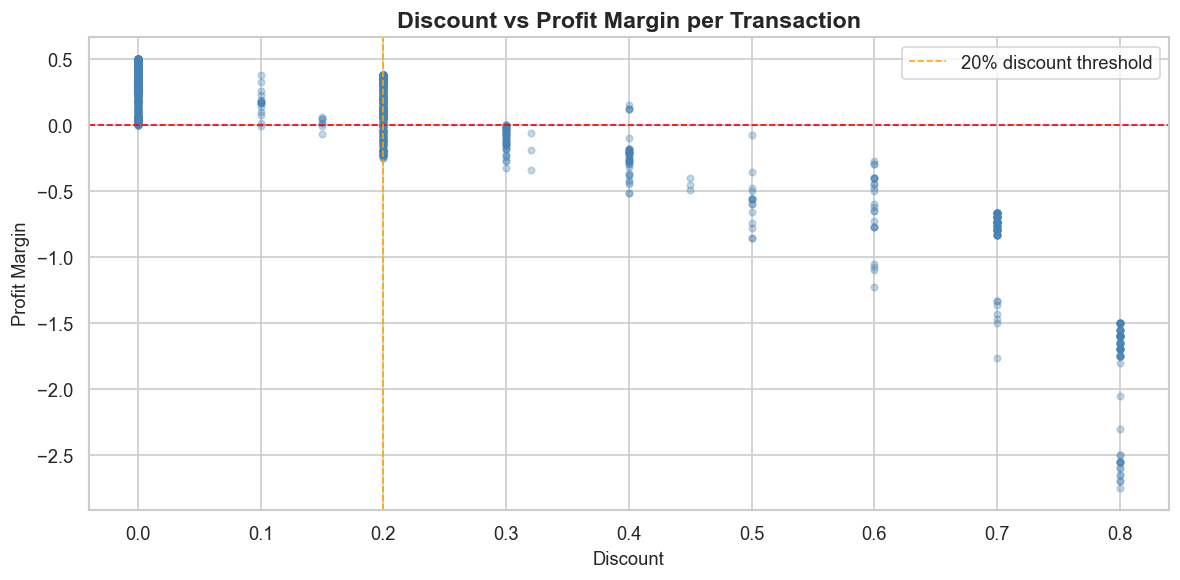

In [14]:
# Scatter: Discount vs Profit Margin — per row
sample = df.sample(n=2000, random_state=42)  # sample for legibility

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample['Discount'], sample['Profit Margin'],
           alpha=0.3, color='steelblue', s=15)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.axvline(0.2, color='orange', linestyle='--', linewidth=1, label='20% discount threshold')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit Margin')
ax.set_title('Discount vs Profit Margin per Transaction', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('discount_margin_scatter')
plt.show()

## 6. Customer Segment Analysis

In [15]:
seg = df.groupby('Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Customers=('Customer ID', 'nunique'),
    Orders=('Order ID', 'nunique')
).assign(
    Margin=lambda x: x['Profit'] / x['Sales'] * 100,
    Avg_Order_Value=lambda x: x['Sales'] / x['Orders']
).sort_values('Profit', ascending=False)

print('Segment Summary:')
seg.style.format({
    'Sales': '${:,.0f}', 'Profit': '${:,.0f}',
    'Margin': '{:.1f}%', 'Avg_Order_Value': '${:,.0f}'
})

Segment Summary:


,Sales,Profit,Customers,Orders,Margin,Avg_Order_Value
Segment,,,,,,
Consumer,"$1,161,401","$134,119",409,2586,11.5%,$449
Corporate,"$706,146","$91,979",236,1514,13.0%,$466
Home Office,"$429,653","$60,299",148,909,14.0%,$473


Saved → ../reports/figures/segment_performance.png


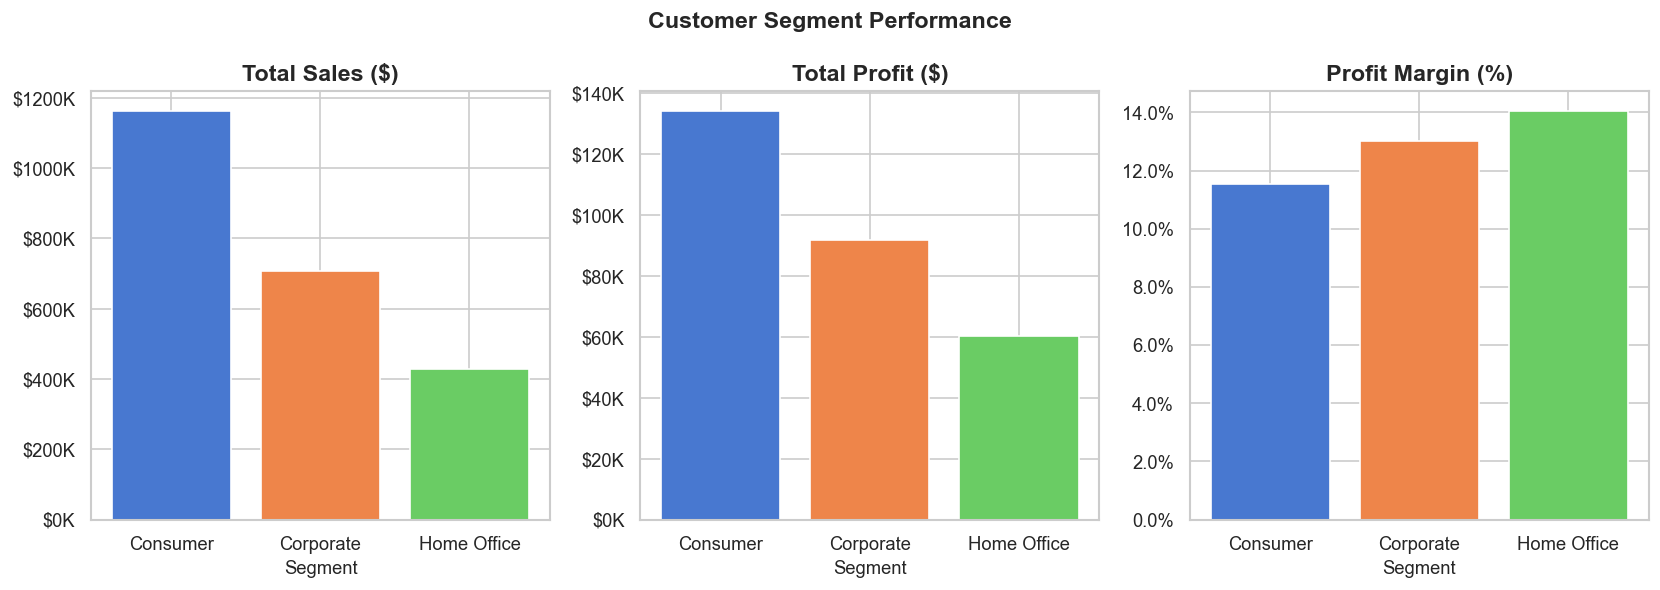

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

palette = sns.color_palette('muted', 3)

for ax, metric, label in zip(axes,
                              ['Sales', 'Profit', 'Margin'],
                              ['Total Sales ($)', 'Total Profit ($)', 'Profit Margin (%)']):
    vals = seg[metric]
    ax.bar(vals.index, vals.values, color=palette)
    if metric != 'Margin':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax.set_title(label)
    ax.set_xlabel('Segment')

plt.suptitle('Customer Segment Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('segment_performance')
plt.show()

Saved → ../reports/figures/segment_category_heatmap.png


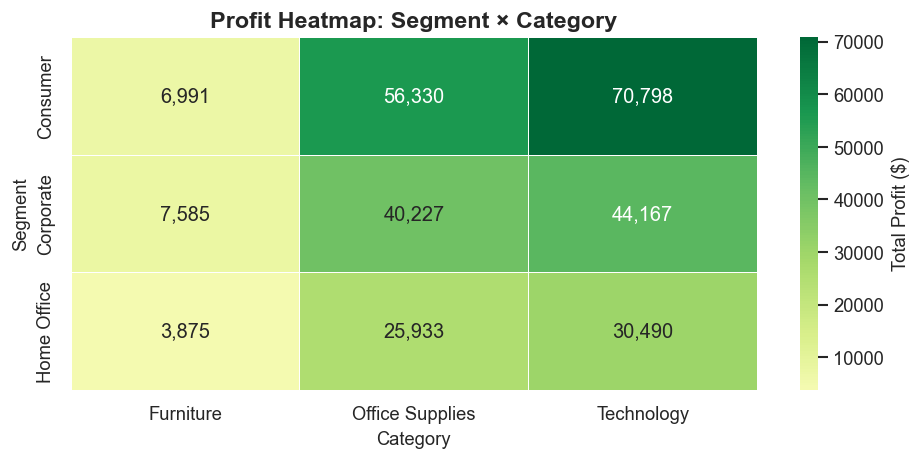

In [17]:
# Segment × Category heatmap
pivot = df.pivot_table(values='Profit', index='Segment', columns='Category', aggfunc='sum')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='RdYlGn', linewidths=0.5,
            center=0, ax=ax, cbar_kws={'label': 'Total Profit ($)'})
ax.set_title('Profit Heatmap: Segment × Category', fontweight='bold')
plt.tight_layout()
save_fig('segment_category_heatmap')
plt.show()

## 7. Key Insights Summary

In [18]:
print("""
======================================================
 KEY BUSINESS INSIGHTS — Superstore 2014–2017
======================================================

1. REVENUE & PROFIT
   Total revenue of $2,297,201 with $286,397 profit
   → Overall margin of 12.5%
   → Revenue grew year-over-year but margin fluctuated
   → Q4 is consistently the strongest quarter every year

2. CATEGORIES
   Technology   : 17.4% margin ($145K profit) ← best
   Office Supplies: 17.0% margin ($122K profit) ← consistent
   Furniture    : 2.5% margin ($18K profit) ← problem
   → Tables sub-category: -$17,725 (net loss)
   → Bookcases sub-category: -$3,473 (net loss)

3. REGIONS
   West    : $108K profit ← leader
   East    : $92K profit
   South   : $47K profit
   Central : $40K profit ← underperformer (heavy discounting)

4. DISCOUNTING
   → Discounts above 20% produce NEGATIVE average profit
   → High (41%+) discount band: severely negative margins
   → Discount policy is the #1 controllable profit lever

5. SEGMENTS
   Consumer    : largest revenue share
   Corporate   : highest margin efficiency
   Home Office : smallest but most consistent margin
======================================================
""")


 KEY BUSINESS INSIGHTS — Superstore 2014–2017

1. REVENUE & PROFIT
   Total revenue of $2,297,201 with $286,397 profit
   → Overall margin of 12.5%
   → Revenue grew year-over-year but margin fluctuated
   → Q4 is consistently the strongest quarter every year

2. CATEGORIES
   Technology   : 17.4% margin ($145K profit) ← best
   Office Supplies: 17.0% margin ($122K profit) ← consistent
   Furniture    : 2.5% margin ($18K profit) ← problem
   → Tables sub-category: -$17,725 (net loss)
   → Bookcases sub-category: -$3,473 (net loss)

3. REGIONS
   West    : $108K profit ← leader
   East    : $92K profit
   South   : $47K profit
   Central : $40K profit ← underperformer (heavy discounting)

4. DISCOUNTING
   → Discounts above 20% produce NEGATIVE average profit
   → High (41%+) discount band: severely negative margins
   → Discount policy is the #1 controllable profit lever

5. SEGMENTS
   Consumer    : largest revenue share
   Corporate   : highest margin efficiency
   Home Office : sma